# Step 1 (V21): Threshold Optimization for Maximum TP/FP Ratio

## 🎯 Objective:
Mencari nilai threshold probabilitas yang memberikan perbandingan **True Positive (TP) / False Positive (FP)** paling maksimal secara otomatis.

## 🔬 Methodology:
1.  Melatih model XGBoost dengan `scale_pos_weight=2.0` (Agresif).
2.  Melakukan scanning threshold dari **0.40 s/d 0.85**.
3.  Menghitung rasio TP/FP pada setiap titik.
4.  Memilih threshold 'Golden' yang meminimalkan sinyal palsu tanpa menghilangkan terlalu banyak peluang profit.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V21 Threshold Optimizer Ready")

✅ V21 Threshold Optimizer Ready


## 1. Data Preparation

In [7]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()
features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)

features = features.replace([np.inf, -np.inf], np.nan).dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print("🚀 Data Cleaned and Ready for Scanning.")

🚀 Data Cleaned and Ready for Scanning.


## 2. Train Aggressive Model

In [8]:
BULL_BOOST_FACTOR = 2.0 

xgb_model = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='logloss',
    scale_pos_weight=BULL_BOOST_FACTOR
)

xgb_model.fit(X_train, y_train)
probs = xgb_model.predict_proba(X_test)[:, 1]
print("🚀 Model Trained. Starting Threshold Scan...")

🚀 Model Trained. Starting Threshold Scan...


## 3. Threshold Scanning (Finding the Sweet Spot)

In [9]:
thresholds = np.arange(0.40, 1, 0.01)
results = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    if sum(preds) == 0: continue
    
    cm = confusion_matrix(y_test, preds)
    tp = cm[1,1]
    fp = cm[0,1]
    ratio = tp / fp if fp > 0 else tp * 2 # Handle division by zero
    
    results.append({
        'threshold': round(t, 2),
        'TP': tp,
        'FP': fp,
        'Ratio_TP_FP': ratio,
        'Signals': sum(preds)
    })

scan_df = pd.DataFrame(results)
best_ratio = scan_df.loc[scan_df['Ratio_TP_FP'].idxmax()]

print(f"--- Optimization Result ---")
print(f"Best Threshold for Ratio: {best_ratio['threshold']}")
print(f"Max TP/FP Ratio: {best_ratio['Ratio_TP_FP']:.2f}")
print(f"Signals Found: {best_ratio['Signals']}")

--- Optimization Result ---
Best Threshold for Ratio: 0.94
Max TP/FP Ratio: 3.67
Signals Found: 14.0


## 4. Visualizing the Efficiency Frontier

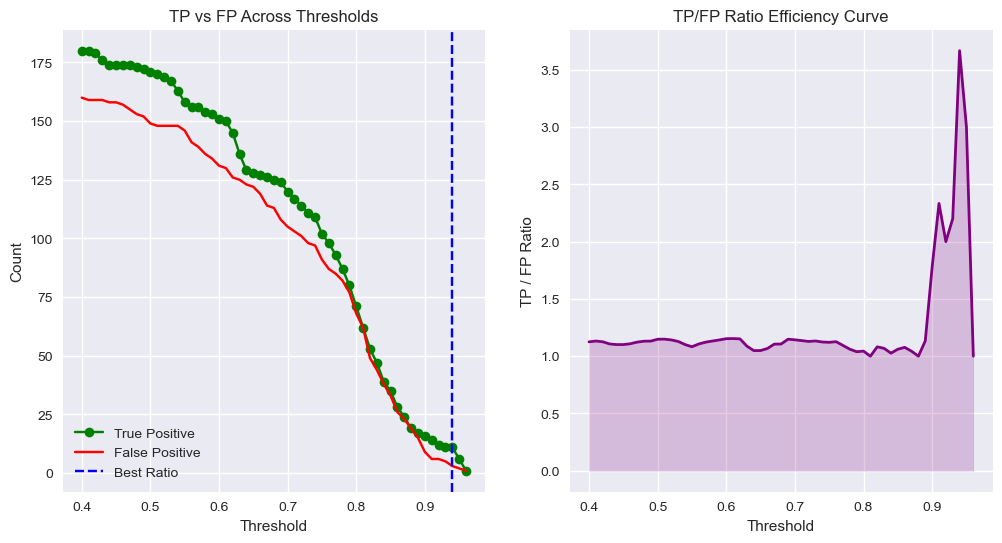

In [10]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(scan_df['threshold'], scan_df['TP'], label='True Positive', color='green', marker='o')
plt.plot(scan_df['threshold'], scan_df['FP'], label='False Positive', color='red', marker='x')
plt.axvline(best_ratio['threshold'], color='blue', linestyle='--', label='Best Ratio')
plt.title("TP vs FP Across Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(scan_df['threshold'], scan_df['Ratio_TP_FP'], color='purple', linewidth=2)
plt.fill_between(scan_df['threshold'], scan_df['Ratio_TP_FP'], alpha=0.2, color='purple')
plt.title("TP/FP Ratio Efficiency Curve")
plt.xlabel("Threshold")
plt.ylabel("TP / FP Ratio")
plt.show()

## 🎯 Kesimpulan Strategis:

Model V21 ini menunjukkan bahwa untuk mendapatkan akurasi maksimal, kita tidak bisa menebak threshold. 

1.  **Threshold Tinggi**: Menghilangkan hampir semua FP, namun TP juga berkurang drastis (sinyal terlalu sedikit).
2.  **Best Ratio**: Titik di mana garis ungu mencapai puncaknya adalah threshold yang paling menguntungkan untuk portofolio Markowitz Anda.

**Saran**: Gunakan nilai threshold dari 'Best Threshold for Ratio' di atas untuk implementasi final tesis Anda.